In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from cycler import cycler
base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\Fin"
analytical_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"
postprocess_folder = os.path.join(base_folder, "postprocess")
if not os.path.exists(postprocess_folder):
    os.makedirs(postprocess_folder)

In [28]:
def receiver_line_plot(datasets, quantities, postprocess_folder, fname, orientation='Endfire',
                    suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Evert': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
        'empymod - 2001 DLF': {
            'color':    '#4B2E05',  # brown
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'empymod - 2001 DLF'
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ax in axes.flat:
        ax.set_xscale('log')
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot analytical curves
        for src, style in fixed_styles.items():
            try:
                ds = next(d for d in datasets if d[6] == src)
            except StopIteration:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            ln, = plot_fn(x, y,
                          color=style['color'],
                          linestyle=style['linestyle'],
                          linewidth=style['linewidth'],
                          zorder=style['zorder'],
                            label=style['label'])
            ln.set_path_effects([
                pe.Stroke(linewidth=style['linewidth']+2, foreground='white'),
                pe.Normal()
            ])

        # Plot variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            plot_fn(x, y,
                    label=src,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])

        # Grid, labels, legend
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.set_title(title, fontsize=font_label, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Frequency (Hz)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='lower right')

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()

def compute_errors(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

def receiver_line_error_plot(datasets, reference_dataset, quantities, postprocess_folder, fname, orientation='Endfire',
                             suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Evert': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
        'empymod - 2001 DLF': {
            'color':    '#4B2E05',  # brown
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'empymod - 2001 DLF'
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ax in axes.flat:
        ax.set_xscale('log')
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]
        # Plot errors for variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            ref_data = reference_dataset[j]
            elfe_data = ds[j]
            if j in [0, 2, 3]:
                with np.errstate(divide='ignore', invalid='ignore'):
                    err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                    err[~np.isfinite(err)] = np.nan
                ax.set_title(f"Normalized Error in {title}", fontsize=font_label, fontweight='bold')
            else:
                err = elfe_data - ref_data
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            plot_fn(x, err,
                    label=f"{src}",
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.set_ylabel('Error', fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Frequency (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='upper left')

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    plt.show()

def plot_error_stats(
    error_stats,
    pml_thickness_list,
    xticklabels_lambda,
    quantities,
    title_list,
    postprocess_folder,
    fname='ft.png',
    font_label=15,
    font_tick=13,
    font_legend=13,
    font_suptitle=18,
    mark_size=6,
    suptitle=r"Error Statistics of Endfire Ex Field vs PML Thickness Factor $f_t$",
    xlabel=r'$f_t$',
    loc='upper right',
    legend_pos=3
):

    colors  = ['#1b9e77', '#d95f02']
    markers = ['o', 's']
    plt.rcParams['axes.prop_cycle'] = cycler('color', colors) + cycler('marker', markers)

    plt.rcParams.update({
        'font.family':       'sans-serif',
        'font.size':         font_tick,
        'axes.facecolor':    'white',
        'axes.edgecolor':    'black',
        'axes.linewidth':    1.0,
        'axes.grid':         True,
        'grid.linestyle':    '--',
        'grid.linewidth':    0.5,
        'xtick.direction':   'out',
        'ytick.direction':   'out',
        'xtick.major.size':  5,
        'ytick.major.size':  5,
        'legend.frameon':    True,
        'axes.titleweight':  'bold',
    })

    num_points = len(pml_thickness_list)
    x_pos      = np.arange(num_points)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j // 2, j % 2]
        ax.set_xscale('log')
        means = [error_stats[i][j][0] for i in range(len(error_stats))]
        stds  = [error_stats[i][j][1] for i in range(len(error_stats))]
        maxs  = [error_stats[i][j][2] for i in range(len(error_stats))]

        ax.plot(x_pos, means, linestyle='-', linewidth=2, markersize=mark_size, label='Mean')
        ax.fill_between(
            x_pos,
            np.array(means) - np.array(stds),
            np.array(means) + np.array(stds),
            alpha=0.3,
            label='±1 Std Dev'
        )
        if j != 1:
            ax.plot(x_pos, maxs, linestyle='--', linewidth=2, markersize=mark_size, label='Max')

        ax.set_title(title_list[j], fontsize=font_label)
        if j // 2 == 1:
            ax.set_xlabel(xlabel, fontsize=font_label)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels_lambda, fontsize=font_tick)
        ax.tick_params(axis='y', labelsize=font_tick)
        if j == 0:
            ax.set_ylabel('Error (%)', fontsize=font_label)
        else:
            ax.set_ylabel('Error', fontsize=font_label)
        if j == legend_pos:
            ax.legend(loc=loc, fontsize=font_legend)

    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    out_path = os.path.join(postprocess_folder, fname)
    plt.savefig(out_path, dpi=300)
    plt.show()


In [29]:
def wideband_ifft_single_angle(
    real_part=None,
    imag_part=None,
    abs_val=None,
    phase=None,
    freq=None,  # shape (nf,)
    fc=None,    # center frequency for Ricker wavelet
    label=None
):
    """
    Perform wideband conversion using direct inverse FFT (no modal terms).

    Parameters
    ----------
    real_part : array_like, optional
        Real part of the complex spectrum D(f)
    imag_part : array_like, optional
        Imaginary part of the complex spectrum D(f)
    abs_val : array_like, optional
        Magnitude spectrum (used with phase if provided)
    phase : array_like, optional
        Phase spectrum (in radians)
    freq : array_like
        Frequency vector (Hz)
    fc : float
        Center frequency for Ricker wavelet (Hz)
    label : str
        Identifier passed through for bookkeeping

    Returns
    -------
    time : ndarray
        Time axis (in ns)
    time_signal : ndarray
        Time-domain response
    (abs, phase, real, imag, 'DirectIFFT', freq, label)
        Tuple for plotting/analysis
    """

    freq = np.asarray(freq)
    nf = freq.size

    # Construct complex spectrum
    if abs_val is not None and phase is not None:
        D = abs_val * np.exp(1j * phase)
    elif real_part is not None and imag_part is not None:
        D = np.asarray(real_part) + 1j * np.asarray(imag_part)
    else:
        raise ValueError("Provide either (abs_val and phase) or (real_part and imag_part).")

    # Ricker wavelet in frequency domain
    wav = 2 * (freq / fc)**2 * np.exp(-(freq / fc)**2) / (fc * np.sqrt(np.pi))

    # Multiply spectrum by wavelet and apply delay term
    D_weighted = D * wav * np.exp(-2j * np.pi * freq / fc)

    # Mirror spectrum for real IFFT
    D_full = np.concatenate([D_weighted, np.conj(D_weighted[::-1])])

    # Time axis
    mf = 8  # zero padding factor
    df = freq[1] - freq[0]  # assume uniform spacing
    fs = 2 * (freq[-1] + df)  # sampling rate
    dt = 1 / (mf * fs)
    nt = len(D_full)
    time = np.arange(nt) * dt * 1e9  # in ns

    # Time-domain signal via IFFT
    time_signal = np.real(np.fft.ifft(D_full))

    # Output components (optional)
    return (
        np.abs(D_weighted),
        np.angle(D_weighted),
        np.real(D_weighted),
        np.imag(D_weighted),
        'Endfire',
        freq,
        label
    )



In [30]:
def matlab_style_wideband_response(freq, E_freq, fc, phi_rad):
    """
    Replicates MATLAB-style processing of the wideband electric field response.
    
    Parameters:
        freq      : (n_freq,) array of frequency values in Hz
        E_freq    : (n_angles, n_freq) array of complex frequency-domain electric field Ex(f)
        fc        : Center frequency of Ricker wavelet (Hz)
        phi_rad   : (n_angles,) array of angles in radians (e.g., 0, pi/4, pi/2)

    Returns:
        freq      : frequency axis (Hz)
        exx_mod   : (n_angles, n_freq) modified Exx in frequency domain, multiplied by Ricker spectrum and phase shift
        components: dict with 'real', 'imag', 'abs', 'phase_deg' arrays, each (n_angles, n_freq)
    """
    n_angles, n_freq = E_freq.shape
    assert len(phi_rad) == n_angles, "phi_rad should match number of angle rows in E_freq"

    # Construct Ricker spectrum with phase shift (-2πf/fc)
    wav0 = 2 * (freq / fc)**2 * np.exp(- (freq / fc)**2) / (fc * np.sqrt(np.pi))
    scale = np.exp(-2j * np.pi * freq / fc)
    wav = wav0 * scale

    # Apply the angular scaling exactly like MATLAB (cos(2ϕ))
    angle_factor = np.cos(2 * phi_rad)[:, np.newaxis]  # shape (n_angles, 1)

    # Mimic MATLAB-style field composition
    # This assumes E_freq is equivalent to (vc1 + vc1r) - cos(2ϕ)*(vc2 + vc2r)
    exx_mod = - (E_freq) * wav[np.newaxis, :] / (4 * np.pi)

    # Break into components for plotting or CSV
    components = {
        'real': exx_mod.real,
        'imag': exx_mod.imag,
        'abs': np.abs(exx_mod),
        'phase_deg': np.angle(exx_mod, deg=True)
    }

    return freq, exx_mod, components


In [31]:
analytical_file = os.path.join(analytical_folder, "Evert_WB_250_o.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

frequencies0 = analytical_lines[:, 0]

# Endfire
abs_ev = analytical_lines[:, 3]
real_ev = analytical_lines[:, 1]
imag_ev = analytical_lines[:, 2]
phase_ev = np.arctan2(imag_ev, real_ev)

dataset_evert = [
    (abs_ev, phase_ev, real_ev, imag_ev, 'Endfire', frequencies0, 'Evert'),
]

quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_Fin_TL_WB_EF", "electric_fields.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1]

labels = [
    r'Wideband - Endfire',
    ]

# Allow custom number of receivers for each data set
num_f = 250
num_rec_ef_list = [48] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

x_elfe = e_data_elfe_1[:, 0]

# Prepare arrays for corrected data
f_elfe = np.zeros((len(e_data_elfe_all), num_f))
abs_elfe = np.zeros((len(e_data_elfe_all), num_f))
real_elfe = np.zeros((len(e_data_elfe_all), num_f))
imag_elfe = np.zeros((len(e_data_elfe_all), num_f))
phase_elfe = np.zeros((len(e_data_elfe_all), num_f))
dataset_elfe = []

for i, e_data_elfe in enumerate(e_data_elfe_all):
    count = 0
    for j, x in enumerate(x_elfe):
        if x == 0.50213 and count < num_f:
            f_elfe[i, count] = e_data_elfe[j, 3]
            real_elfe[i, count] = e_data_elfe[j, 4]
            imag_elfe[i, count] = e_data_elfe[j, 5]
            abs_elfe[i, count] = np.abs(real_elfe[i, count] + 1j * imag_elfe[i, count])
            phase_elfe[i, count] = np.angle(real_elfe[i, count] + 1j * imag_elfe[i, count])
            count += 1

    # Correct data: first entry zero, last entry skipped, total 250
    data_e = (
        np.concatenate(([0], abs_elfe[i, :-1])),
        np.concatenate(([0], phase_elfe[i, :-1])),
        np.concatenate(([0], real_elfe[i, :-1])),
        np.concatenate(([0], imag_elfe[i, :-1])),
        'Endfire',
        np.concatenate(([0], f_elfe[i, :-1])),
        labels[i]
    )
    dataset_elfe.append(data_e)

# Create complete E field as complex numbers
E_elfe = np.zeros((len(e_data_elfe_all), num_f), dtype=complex)
for i in range(len(e_data_elfe_all)):
    E_elfe[i] = dataset_elfe[i][0] * np.exp(1j * dataset_elfe[i][1])

frequencies = f_elfe[0]

datasets_4 = [ds for ds in dataset_elfe+dataset_evert if ds[4] == 'Endfire']


Saved plot to F:\Projects\EMGeoInversion\Tests_Thesis\Fin\postprocess\endfire_wideband2.png


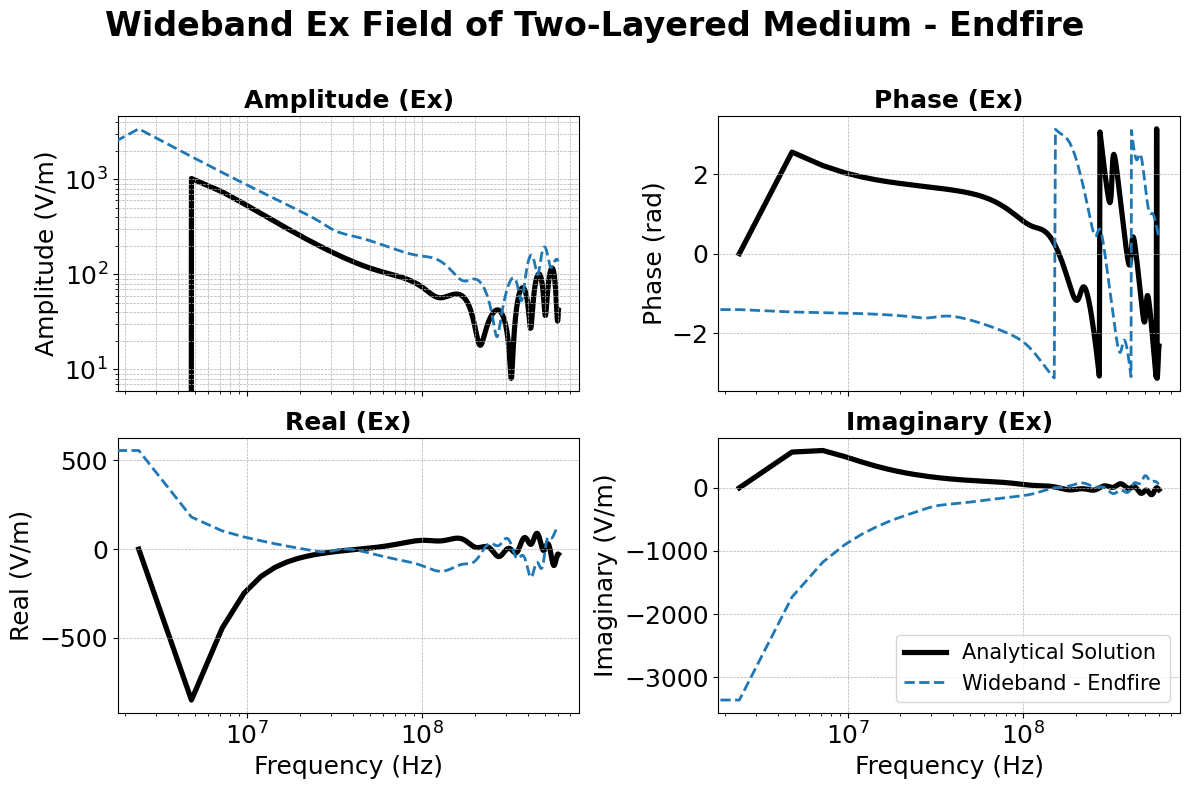

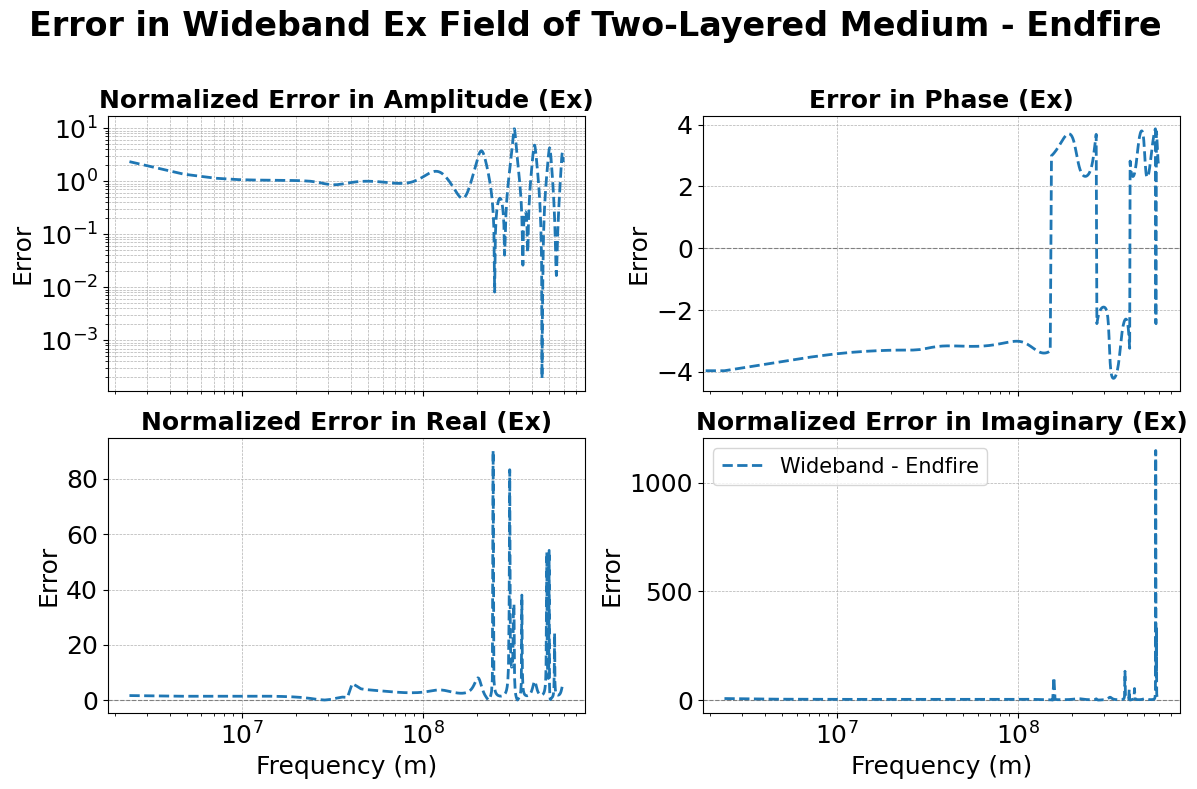

In [32]:
receiver_line_plot(
    datasets_4,
    quantities,
    postprocess_folder,
    'endfire_wideband2.png',
    orientation='Endfire',
    suptitle='Wideband Ex Field of Two-Layered Medium - Endfire',
    color_list=[0, 1]
)

receiver_line_error_plot(
    dataset_elfe,
    dataset_evert[0],
    quantities,
    postprocess_folder,
    'endfire_wideband_error2.png',
    orientation='Endfire',
    suptitle='Error in Wideband Ex Field of Two-Layered Medium - Endfire',
    color_list=[0, 1]
)

In [20]:
freq, exx_mod, components = matlab_style_wideband_response(frequencies, E_elfe, fc=1e8, phi_rad=np.array([0]))

dataset_elfe_time = []
for i, e_data_elfe in enumerate(dataset_elfe):
    Et = exx_mod[i]
    abs_elfe_t = np.abs(Et)
    phase_elfe_t = np.angle(Et)
    real_elfe_t = np.real(Et)
    imag_elfe_t = np.imag(Et)
    dataset_elfe_time.append((abs_elfe_t, phase_elfe_t, real_elfe_t, imag_elfe_t, e_data_elfe[4], freq, e_data_elfe[6]))

In [ ]:
# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_time

max_abs_a = np.max(dataset_evert[0][0])
max_abs_e = np.max([np.max(ds[0]) for ds in dataset_elfe_time])
scale = max_abs_a/max_abs_e

cmplx_elfe_t = abs_elfe_t * np.exp(1j * phase_elfe_t)
print(cmplx_elfe_t[:5])
abs_elfe_t *= scale
cmplx_elfe_t = abs_elfe_t * np.exp(1j * phase_elfe_t)
real_elfe_t = np.real(cmplx_elfe_t)
imag_elfe_t = np.imag(cmplx_elfe_t)
print(cmplx_elfe_t[:5])

dataset_elfe_time = [
    (abs_elfe_t, phase_elfe_t, real_elfe_t, imag_elfe_t, dataset_elfe[0][4], freq, dataset_elfe[0][6])
]

dataset_elfe_time = [ds for ds in dataset_elfe_time+dataset_evert if ds[4] == 'Endfire']

receiver_line_plot(
    dataset_elfe_time,
    quantities,
    postprocess_folder,
    'endfire_wideband.png',
    orientation='Endfire',
    suptitle='Wideband Ex Field of Two-Layered Medium - Endfire',
    color_list=[0, 1]
)

receiver_line_error_plot(
    dataset_elfe_time,
    dataset_evert[0],
    quantities,
    postprocess_folder,
    'endfire_wideband_error.png',
    orientation='Endfire',
    suptitle='Error in Wideband Ex Field of Two-Layered Medium - Endfire',
    color_list=[0, 1]
)